In [1]:
%load_ext autoreload
%matplotlib inline
%autoreload 2
import numpy as np
import getdist
from getdist import plots, MCSamples
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append("../../")
from cosmosis.postprocessing.inputs import read_input as _cosmosis_read

In [2]:
names_both = ['7', '8', '1', '2', '3', '4', '5', '6']
labels_both = [r'$\ln \lambda_0$', r'$\mu_z$', r'$\mu_m$', r'$\sigma_{\ln \lambda, 0}$', r'$\sigma_m$', r'$\sigma_z$', r'$\Omega_8$', r'$\sigma_8$']

names_mor = ['1', '2', '3', '4', '5', '6']
labels_mor = [r'$\ln \lambda_0$', r'$\mu_z$', r'$\mu_m$', r'$\sigma_{\ln \lambda, 0}$', r'$\sigma_m$', r'$\sigma_z$']


settings={'mult_bias_correction_order':0,'smooth_scale_2D':4, 'smooth_scale_1D':4, 'boundary_correction_order':0}

In [3]:
import sys
sys.path.append("../../")
from clpipe.utils.cosmosis_mcmc_plots import fits_to_samples

def load_cosmosis_chain(
    fits_path: str,
    param_names: list[str],
    burn_fraction: float = 0.15,
    skip_cosmo = False,
    only_cosmo = False,
    label = None,
) -> MCSamples:
    full = fits_to_samples([fits_path], burn_fraction=burn_fraction)[0]
    n_par = len(param_names)

    if skip_cosmo:
        keep_idx = list(range(2, n_par))
        out_names = param_names[2:]
    elif only_cosmo:
        keep_idx = [0, 1]
        out_names = param_names[:2]
    else:
        keep_idx = list(range(n_par))
        out_names = param_names

    array = full.samples[:, keep_idx]
    samples = MCSamples(
        samples  = array,
        names    = out_names,
        labels   = out_names,
        settings = settings,
        label    = label,
    )
    return samples


## Baseline

In [4]:
path_baseline_both = "../../data/cosmodc2_redmapper/chains/both_full.fits"  # was: ./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt

baseline_both = load_cosmosis_chain(path_baseline_both, names_both, label = "Baseline Counts+Lensing", only_cosmo=True)


Removed no burn in
  Loaded 2,385,100 samples + loglike (both_full)  ← ../../data/cosmodc2_redmapper/chains/both_full.fits
Removed no burn in


## HMF

In [5]:
tinker08_both_path = "../../data/cosmodc2_redmapper/chains/both_tinker08.fits"
tinker10_both_path = "../../data/cosmodc2_redmapper/chains/both_tinker10.fits"
bocquet16_both_path = "../../data/cosmodc2_redmapper/chains/both_bocquet16.fits"

tinker08_both = load_cosmosis_chain(tinker08_both_path, names_both, label = "Tinker08", only_cosmo=True)
tinker10_both = load_cosmosis_chain(tinker10_both_path, names_both, label = "Tinker10", only_cosmo=True)
bocquet16_both = load_cosmosis_chain(bocquet16_both_path, names_both, label = "Bocquet16", only_cosmo=True)


Removed no burn in
  Loaded 2,118,200 samples + loglike (both_tinker08)  ← ../../data/cosmodc2_redmapper/chains/both_tinker08.fits
Removed no burn in
Removed no burn in
  Loaded 2,034,900 samples + loglike (both_tinker10)  ← ../../data/cosmodc2_redmapper/chains/both_tinker10.fits
Removed no burn in
Removed no burn in
  Loaded 2,312,000 samples + loglike (both_bocquet16)  ← ../../data/cosmodc2_redmapper/chains/both_bocquet16.fits
Removed no burn in


## Fiducial Cosmology

In [6]:
cosmo0227_both_path = "../../data/cosmodc2_redmapper/chains/both_cosmo_0.22_0.7.fits"
cosmo0229_both_path = "../../data/cosmodc2_redmapper/chains/both_cosmo_0.22_0.9.fits"

cosmo227_both = load_cosmosis_chain(cosmo0227_both_path, names_both, label = f'$\Omega_c = 0.22$, $\sigma_8 = 0.7$', only_cosmo=True)
cosmo229_both = load_cosmosis_chain(cosmo0229_both_path, names_both, label = f'$\Omega_c = 0.22$, $\sigma_8 = 0.9$', only_cosmo=True)


Removed no burn in
  Loaded 2,548,300 samples + loglike (both_cosmo_0.22_0.7)  ← ../../data/cosmodc2_redmapper/chains/both_cosmo_0.22_0.7.fits
Removed no burn in
Removed no burn in
  Loaded 1,863,200 samples + loglike (both_cosmo_0.22_0.9)  ← ../../data/cosmodc2_redmapper/chains/both_cosmo_0.22_0.9.fits
Removed no burn in


In [7]:
list_chain_baseline = [baseline_both]
likelihood_baseline = ["Counts+Lensing"]
list_chains_hmf = [tinker08_both, tinker10_both, bocquet16_both]
likelihood_hmf = ['tinker08_cosmo', 'tinker10_cosmo','bocquet16_cosmo']
list_chains_ds = [cosmo227_both, cosmo229_both]
likelihood_ds = [f'$\Omega_c 0.22, \sigma_8 0.7$', f'$\Omega_c 0.22, \sigma_8 0.9$']

sections = [list_chain_baseline, list_chains_hmf, list_chains_ds]
color_section = ['C0', 'C1', 'C2']
baseline_per_section = [baseline_both, baseline_both, baseline_both]

sections_name = ['Baseline', 'HMF', f'Fiducial Cosmo']


truth = {'7': 0.22,
 '8': 0.8}




Baseline Counts+Lensing [0.25040609 0.77536508] lo1/hi1: [np.float64(0.06741768827863864), np.float64(0.08369459937849322)] [np.float64(0.05076914027922691), np.float64(0.05902486198172352)]
Tinker08 [0.24686317 0.77739055] lo1/hi1: [np.float64(0.05486728460451004), np.float64(0.07428574326108761)] [np.float64(0.0423923845159726), np.float64(0.05378541327655462)]
Tinker10 [0.23631562 0.76628269] lo1/hi1: [np.float64(0.05182793479268338), np.float64(0.0658185757577876)] [np.float64(0.0396523014999178), np.float64(0.05002131107243335)]
Bocquet16 [0.23814893 0.76528707] lo1/hi1: [np.float64(0.05544681707747759), np.float64(0.06677612986622194)] [np.float64(0.04268704772401044), np.float64(0.048644782636096506)]
$\Omega_c = 0.22$, $\sigma_8 = 0.7$ [0.22494523 0.80142722] lo1/hi1: [np.float64(0.05207968188907583), np.float64(0.06842186311276222)] [np.float64(0.03626030495552826), np.float64(0.05720037194926686)]
$\Omega_c = 0.22$, $\sigma_8 = 0.9$ [0.24517575 0.77841531] lo1/hi1: [np.float6

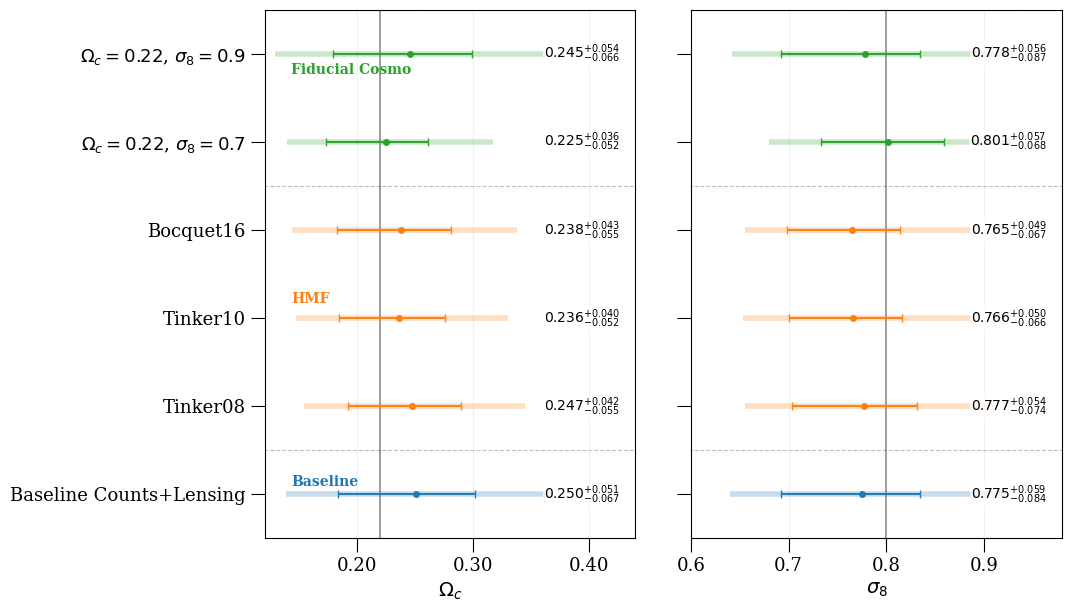

In [12]:
%matplotlib inline
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import matplotlib.pyplot as plt

params_cosmo = ['7', '8']
truth = {'7': 0.22, '8': 0.80}
xlabels = {
    '7': r'$\Omega_c$',
    '8': r'$\sigma_8$',
}
number_of_params = 2


def get_marge_limits(mcmc, params, means):
    """1-sigma / 2-sigma asymmetric credible intervals from getdist's own
    marginalized-density limits (MCSamples.getMargeStats(), the same
    machinery _print_constraints in cosmosis_mcmc_plots.py uses via
    getInlineLatex) -- not raw order-statistic percentiles, and not a
    symmetric Gaussian sigma from the covariance."""
    stats = mcmc.getMargeStats()
    lo1, hi1, lo2, hi2 = [], [], [], []
    for k, par_name in enumerate(params):
        par = stats.parWithName(par_name)
        l1, l2 = par.limits[0], par.limits[1]  # getdist default levels: 68%, 95%, 99%
        lo1.append(means[k] - l1.lower); hi1.append(l1.upper - means[k])
        lo2.append(means[k] - l2.lower); hi2.append(l2.upper - means[k])
    return lo1, hi1, lo2, hi2


fig, ax = plt.subplots(
    1,
    number_of_params,
    figsize=(11, 7),
    sharey=True,
)
plt.subplots_adjust(wspace=0.15)

y = 0
yticks = []
yticklabels = []
for l, section in enumerate(sections):
    color = color_section[l]
    section_start = y
    for mcmc in section:
        means = mcmc.mean(params_cosmo)
        lo1, hi1, lo2, hi2 = get_marge_limits(mcmc, params_cosmo, means)
        print(mcmc.label, means, "lo1/hi1:", lo1, hi1)

        yticks.append(y)
        yticklabels.append(mcmc.label)

        for j, par in enumerate(params_cosmo):
            # 2 sigma: light, wide, behind
            ax[j].errorbar(
                means[j],
                y,
                xerr=[[lo2[j]], [hi2[j]]],
                marker='none',
                color=color,
                alpha=0.25,
                lw=4.0,
                capsize=0,
                zorder=1,
            )
            # 1 sigma: darker, thinner, on top
            ax[j].errorbar(
                means[j],
                y,
                xerr=[[lo1[j]], [hi1[j]]],
                marker='o',
                color=color,
                alpha=0.95,
                lw=1.5,
                capsize=3,
                markersize=4,
                zorder=2,
            )
            # value label, asymmetric
            label = rf"${means[j]:.3f}^{{+{hi1[j]:.3f}}}_{{-{lo1[j]:.3f}}}$"
            ax[j].text(
                0.96, y, label,
                transform=ax[j].get_yaxis_transform(),  # x: axes fraction, y: data coords
                ha='right', va='center',
                fontsize=10,
                color='black',
                zorder=3,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1),
            )
        y += 1

    section_end = y - 1
    # group separator
    for j in range(number_of_params):
        ax[j].hlines(
            y - 0.5,
            -10,
            10,
            ls='--',
            color='0.75',
            lw=0.8,
            zorder=0,
        )
    y_section = 0.52 * (section_start + section_end)
    y_section += 0.14

    # section label
    ax[0].text(
        0.143,
        y_section,
        sections_name[l],
        ha='left',
        va='center',
        color=color,
        fontweight='bold',
        fontsize=10,
    )

# Fiducial vertical lines
for j, par in enumerate(params_cosmo):
    ax[j].axvline(
        truth[par],
        color='k',
        lw=1.2,
        alpha=0.45,
        zorder=0,
    )
    ax[j].set_xlabel(xlabels[par], fontsize=14)
    ax[j].tick_params(axis='both', which='both', labelsize=13)
    ax[j].grid(axis='x', alpha=0.2)

ax[0].set_yticks(yticks)
ax[0].set_yticklabels(yticklabels, fontsize=13)
ax[0].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# widened xlim to leave room for the text labels on the right
ax[0].set_xlim(0.12, 0.44)
ax[1].set_xlim(0.6, 0.98)
ax[0].set_ylim(-0.5, y - 0.5)

plt.savefig("./figures/summary_cosmo.pdf", bbox_inches='tight', dpi=150)
plt.show()

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Tension metrics: fiducial recovery and baseline shifts
# ============================================================

params_cosmo = ['7', '8']

param_latex = {
    '7': r'$\Omega_c$',
    '8': r'$\sigma_8$',
}

truth = {
    '7': 0.22,
    '8': 0.80,
}

# Use zero if fiducials are exact simulation/input values.
# If later you have uncertainties on the fiducial values, replace these.
truth_err = {
    '7': 0.0,
    '8': 0.0,
}


def mean_and_marge_error(chain, params):
    """Posterior mean + a single effective sigma per parameter, from
    getdist's own marginalized-density 68% limits (same machinery as
    get_marge_limits above / _print_constraints in cosmosis_mcmc_plots.py)
    rather than sqrt(diag(cov)). The interval is generally asymmetric;
    averaging the two sides into one effective sigma keeps the tension
    formulas below unchanged, at the cost of not tracking the skew.
    """
    mean = np.asarray(chain.mean(params))
    stats = chain.getMargeStats()
    err = np.array([
        0.5 * ((stats.parWithName(p).limits[0].upper - m) + (m - stats.parWithName(p).limits[0].lower))
        for p, m in zip(params, mean)
    ])
    return mean, err


def tension_wrt_fiducial(chain, params, truth, truth_err=None):
    mean, err = mean_and_marge_error(chain, params)

    fid = np.array([truth[p] for p in params], dtype=float)

    if truth_err is None:
        fid_err = np.zeros_like(fid)
    else:
        fid_err = np.array([truth_err[p] for p in params], dtype=float)

    t_fid = (mean - fid) / np.sqrt(err**2 + fid_err**2)

    return t_fid


def tension_wrt_baseline(chain, baseline_chain, params):
    mean, err = mean_and_marge_error(chain, params)
    base_mean, base_err = mean_and_marge_error(baseline_chain, params)

    t_base = (mean - base_mean) / np.sqrt(err**2 + base_err**2)

    return t_base


# ============================================================
# Build table
# ============================================================

rows = []

for section_name, section, baseline_chain in zip(
    sections_name,
    sections,
    baseline_per_section,
):
    for chain in section:
        mean, err = mean_and_marge_error(chain, params_cosmo)
        t_fid = tension_wrt_fiducial(chain, params_cosmo, truth, truth_err)
        t_base = tension_wrt_baseline(chain, baseline_chain, params_cosmo)

        for i, p in enumerate(params_cosmo):
            rows.append({
                "section": section_name,
                "chain": chain.label,
                "param": p,
                "param_label": param_latex[p],
                "mean": mean[i],
                "sigma": err[i],
                "fiducial": truth[p],
                "T_fid": t_fid[i],
                "abs_T_fid": abs(t_fid[i]),
                "T_base": t_base[i],
                "abs_T_base": abs(t_base[i]),
            })

df_tension = pd.DataFrame(rows)

df_tension

,section,chain,param,param_label,mean,sigma,fiducial,T_fid,abs_T_fid,T_base,abs_T_base
0,Baseline,Baseline Counts+Lensing,7,$\Omega_c$,0.250406,0.059093,0.22,0.514543,0.514543,0.000000,0.000000
1,Baseline,Baseline Counts+Lensing,8,$\sigma_8$,0.775365,0.071360,0.80,-0.345222,0.345222,0.000000,0.000000
2,HMF,Tinker08,7,$\Omega_c$,0.246863,0.048630,0.22,0.552401,0.552401,-0.046294,0.046294
3,HMF,Tinker08,8,$\sigma_8$,0.777391,0.064036,0.80,-0.353076,0.353076,0.021125,0.021125
4,HMF,Tinker10,7,$\Omega_c$,0.236316,0.045740,0.22,0.356703,0.356703,-0.188558,0.188558
5,HMF,Tinker10,8,$\sigma_8$,0.766283,0.057920,0.80,-0.582136,0.582136,-0.098821,0.098821
6,HMF,Bocquet16,7,$\Omega_c$,0.238149,0.049067,0.22,0.369881,0.369881,-0.159580,0.159580
7,HMF,Bocquet16,8,$\sigma_8$,0.765287,0.057710,0.80,-0.601501,0.601501,-0.109812,0.109812
8,Fiducial Cosmo,"$\Omega_c = 0.22$, $\sigma_8 = 0.7$",7,$\Omega_c$,0.224945,0.044170,0.22,0.111959,0.111959,-0.345107,0.345107
9,Fiducial Cosmo,"$\Omega_c = 0.22$, $\sigma_8 = 0.7$",8,$\sigma_8$,0.801427,0.062811,0.80,0.022722,0.022722,0.274149,0.274149


In [10]:
# ============================================================
# Compact summary for paper text
# ============================================================

# Main baseline recovery relative to fiducial
# Use the combined Counts+Lensing baseline as the reference.
main_baseline = baseline_both

T_main_fid = tension_wrt_fiducial(
    main_baseline,
    params_cosmo,
    truth,
    truth_err,
)

print("Main baseline recovery:")
for p, t in zip(params_cosmo, T_main_fid):
    print(f"{param_latex[p]:12s}: T_fid = {t:+.2f} sigma")

print()
print(f"Max baseline |T_fid| = {np.max(np.abs(T_main_fid)):.2f} sigma")


# Robustness tests: exclude the first section if you only want non-baseline tests
df_nonbaseline_tests = df_tension[df_tension["section"] != "Baseline"].copy()

max_shift_base = df_nonbaseline_tests["abs_T_base"].max()
max_shift_fid = df_nonbaseline_tests["abs_T_fid"].max()

print()
print("Robustness tests:")
print(f"Max |T_base| = {max_shift_base:.2f} sigma")
print(f"Max |T_fid|  = {max_shift_fid:.2f} sigma")


# Find which chain/parameter gives the largest shifts
idx_base = df_nonbaseline_tests["abs_T_base"].idxmax()
idx_fid = df_nonbaseline_tests["abs_T_fid"].idxmax()

print()
print("Largest baseline shift:")
print(df_nonbaseline_tests.loc[idx_base, ["section", "chain", "param_label", "T_base"]])

print()
print("Largest fiducial offset:")
print(df_nonbaseline_tests.loc[idx_fid, ["section", "chain", "param_label", "T_fid"]])

Main baseline recovery:
$\Omega_c$  : T_fid = +0.51 sigma
$\sigma_8$  : T_fid = -0.35 sigma

Max baseline |T_fid| = 0.51 sigma

Robustness tests:
Max |T_base| = 0.35 sigma
Max |T_fid|  = 0.60 sigma

Largest baseline shift:
section                             Fiducial Cosmo
chain          $\Omega_c = 0.22$, $\sigma_8 = 0.7$
param_label                             $\Omega_c$
T_base                                   -0.345107
Name: 8, dtype: object

Largest fiducial offset:
section               HMF
chain           Bocquet16
param_label    $\sigma_8$
T_fid           -0.601501
Name: 7, dtype: object


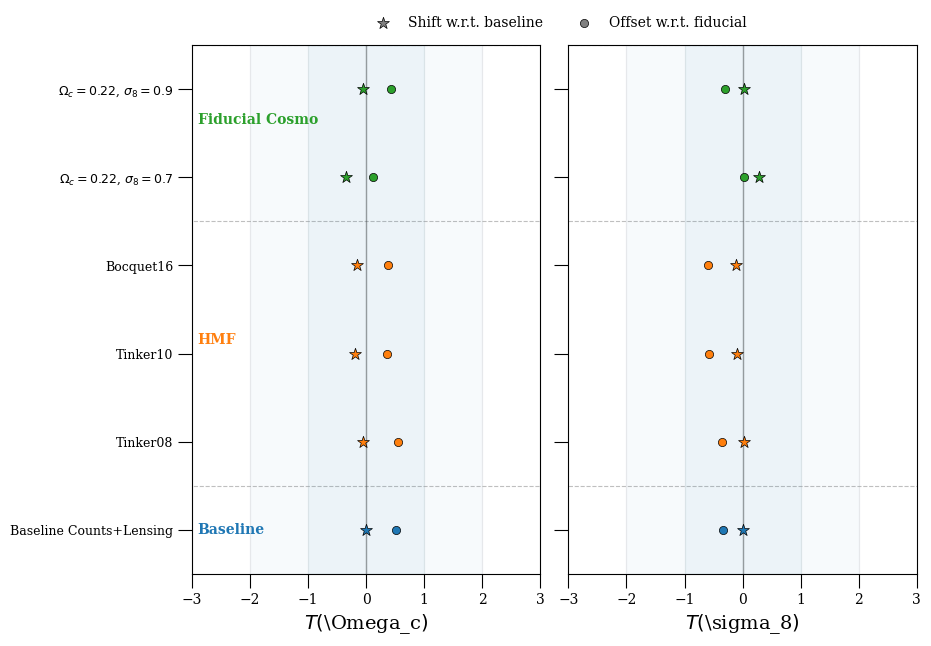

In [11]:
# ============================================================
# Plot: T_fid and T_base for each chain
# ============================================================

fig, ax = plt.subplots(
    1,
    len(params_cosmo),
    figsize=(10, 7),
    sharey=True,
)

plt.subplots_adjust(wspace=0.08)

y = 0
yticks = []
yticklabels = []

for l, (section_name, section, baseline_chain) in enumerate(
    zip(sections_name, sections, baseline_per_section)
):
    color = color_section[l]
    section_start = y

    for chain in section:
        t_fid = tension_wrt_fiducial(chain, params_cosmo, truth, truth_err)
        t_base = tension_wrt_baseline(chain, baseline_chain, params_cosmo)

        yticks.append(y)
        yticklabels.append(chain.label)

        for j, p in enumerate(params_cosmo):
            ax[j].scatter(
                t_base[j],
                y,
                marker="*",
                s=80,
                color=color,
                edgecolors="k",
                linewidths=0.5,
                zorder=3,
            )

            ax[j].scatter(
                t_fid[j],
                y,
                marker="o",
                s=35,
                color=color,
                edgecolors="k",
                linewidths=0.5,
                zorder=3,
            )

        y += 1

    section_end = y - 1

    for j in range(len(params_cosmo)):
        ax[j].hlines(
            y - 0.5,
            -10,
            10,
            ls="--",
            color="0.75",
            lw=0.8,
            zorder=0,
        )

    # section label: midpoint, with small offset only for multi-row sections
    y_section = 0.5 * (section_start + section_end)
    if len(section) > 1:
        y_section += 0.15

    ax[0].text(
        -2.9,
        y_section,
        section_name,
        ha="left",
        va="center",
        color=color,
        fontweight="bold",
        fontsize=10,
    )


for j, p in enumerate(params_cosmo):
    ax[j].axvline(0.0, color="k", lw=1.0, alpha=0.4, zorder=0)

    ax[j].axvspan(-1, 1, color="C0", alpha=0.05, zorder=0)
    ax[j].axvspan(-2, 2, color="C0", alpha=0.03, zorder=0)

    ax[j].set_xlim(-3, 3)
    ax[j].set_xlabel(rf"$T({param_latex[p]})$", fontsize=14)
    ax[j].grid(axis="x", alpha=0.2)
    ax[j].tick_params(axis="both", which="both", labelsize=10)

ax[0].set_yticks(yticks)
ax[0].set_yticklabels(yticklabels, fontsize=9)
ax[0].set_ylim(-0.5, y - 0.5)

# Dummy points for legend
ax[0].scatter(
    [],
    [],
    marker="*",
    s=80,
    color="0.5",
    edgecolors="k",
    linewidths=0.5,
    label=r"Shift w.r.t. baseline",
)

ax[0].scatter(
    [],
    [],
    marker="o",
    s=35,
    color="0.5",
    edgecolors="k",
    linewidths=0.5,
    label=r"Offset w.r.t. fiducial",
)

ax[0].legend(
    loc="upper center",
    bbox_to_anchor=(1.05, 1.08),
    ncol=2,
    frameon=False,
    fontsize=10,
)
plt.savefig("./figures/summary_tension_cosmo.pdf", bbox_inches='tight', dpi=150)
plt.show()